# Cross-Language Diarization Performance Comparison

This notebook compares streaming diarization system performance across all **five CallHome language** datasets.

**Languages:**
- English (`callhome_eng`)
- German (`callhome_deu`)
- Japanese (`callhome_jpn`)
- Spanish (`callhome_spa`)
- Mandarin Chinese (`callhome_zho`)

**Metrics Compared:**
- **DER** (Diarization Error Rate) - Overall error including FA, Miss, and Confusion
- **Detection Error** - False Alarm + Missed Detection (speaker-agnostic)
- **JER** (Jaccard Error Rate) - Frame-level overlap error metric

**Systems:**
- `diart_default` - DIART with default parameters
- `diart_custom` - DIART with custom parameters
- `streaming_sortformer` - Streaming SortFormer system


## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import analysis modules
import data_loader
import stats_report

# Auto-reload modules when they change
%load_ext autoreload
%autoreload 2

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

## Load Data from All Five Languages


In [2]:
# Load results for all five CallHome languages
eng_path = Path("../results/callhome_eng/metrics.csv")
df_eng = data_loader.load_metrics(eng_path, verbose=False)
df_eng['language'] = 'English'

deu_path = Path("../results/callhome_deu/metrics.csv")
df_deu = data_loader.load_metrics(deu_path, verbose=False)
df_deu['language'] = 'German'

jpn_path = Path("../results/callhome_jpn/metrics.csv")
df_jpn = data_loader.load_metrics(jpn_path, verbose=False)
df_jpn['language'] = 'Japanese'

spa_path = Path("../results/callhome_spa/metrics.csv")
df_spa = data_loader.load_metrics(spa_path, verbose=False)
df_spa['language'] = 'Spanish'

zho_path = Path("../results/callhome_zho/metrics.csv")
df_zho = data_loader.load_metrics(zho_path, verbose=False)
df_zho['language'] = 'Mandarin'

# Combine all datasets
df_combined = pd.concat([df_eng, df_deu, df_jpn, df_spa, df_zho], ignore_index=True)

print(f"English recordings:  {df_eng['recording_id'].nunique()}")
print(f"German recordings:   {df_deu['recording_id'].nunique()}")
print(f"Japanese recordings: {df_jpn['recording_id'].nunique()}")
print(f"Spanish recordings:  {df_spa['recording_id'].nunique()}")
print(f"Mandarin recordings: {df_zho['recording_id'].nunique()}")
print(f"Systems: {df_combined['system'].unique().tolist()}")
print(f"\nTotal rows: {len(df_combined)}")


English recordings:  140
German recordings:   120
Japanese recordings: 120
Spanish recordings:  140
Mandarin recordings: 140
Systems: ['diart_default', 'diart_custom', 'streaming_sortformer']

Total rows: 1980


## Calculate Detection Error Rate

Detection Error = False Alarm + Missed Detection (excludes speaker confusion)

In [3]:
# Add Detection Error Rate column
df_combined['detection_error'] = (df_combined['false_alarm'] + 
                                   df_combined['missed_detection']) / df_combined['total_speech_time']

# Verify calculation
print("Sample Detection Error values:")
print(df_combined[['system', 'language', 'DER', 'detection_error', 'JER']].head(10))

Sample Detection Error values:
          system language     DER  detection_error     JER
0  diart_default  English  0.1707           0.1226  0.2458
1  diart_default  English  0.3934           0.1913  0.4852
2  diart_default  English  0.4511           0.1481  0.6323
3  diart_default  English  0.4839           0.2502  0.5901
4  diart_default  English  0.4796           0.1173  0.6330
5  diart_default  English  0.2896           0.1505  0.4963
6  diart_default  English  0.4909           0.2644  0.6715
7  diart_default  English  0.3445           0.2454  0.4611
8  diart_default  English  0.3188           0.1347  0.5678
9  diart_default  English  0.4907           0.1335  0.6564


## Summary Statistics by Language and System

In [4]:
# Calculate mean metrics by language and system
summary = df_combined.groupby(['language', 'system']).agg({
    'DER': 'mean',
    'detection_error': 'mean',
    'JER': 'mean',
    'recording_id': 'count'
}).rename(columns={'recording_id': 'num_recordings'})

print("Mean Performance by Language and System:")
print("="*80)
display(summary.round(4))

Mean Performance by Language and System:


DER  detection_error     JER  num_recordings
language system                                                               
English  diart_custom          0.4162           0.1700  0.4857             140
         diart_default         0.4221           0.1664  0.5276             140
         streaming_sortformer  0.2024           0.1757  0.2144             140
German   diart_custom          0.4005           0.1746  0.4908             120
         diart_default         0.4329           0.1827  0.5257             120
         streaming_sortformer  0.1913           0.1524  0.2070             120
Japanese diart_custom          0.4609           0.2416  0.5580             120
         diart_default         0.5451           0.2471  0.6125             120
         streaming_sortformer  0.2458           0.1866  0.2643             120
Mandarin diart_custom          0.4247           0.1766  0.5301             140
         diart_default         0.4424           0.1765  0.5572             140
         streaming_sortformer  0.2295           0.1802  0.2705             140
Spanish  diart_custom          0.5151           0.3260  0.5804             140
         diart_default         0.5942           0.3329  0.6481             140
         streaming_sortformer  0.2972           0.2194  0.3387             140

## Visualization: DER Comparison Across Languages

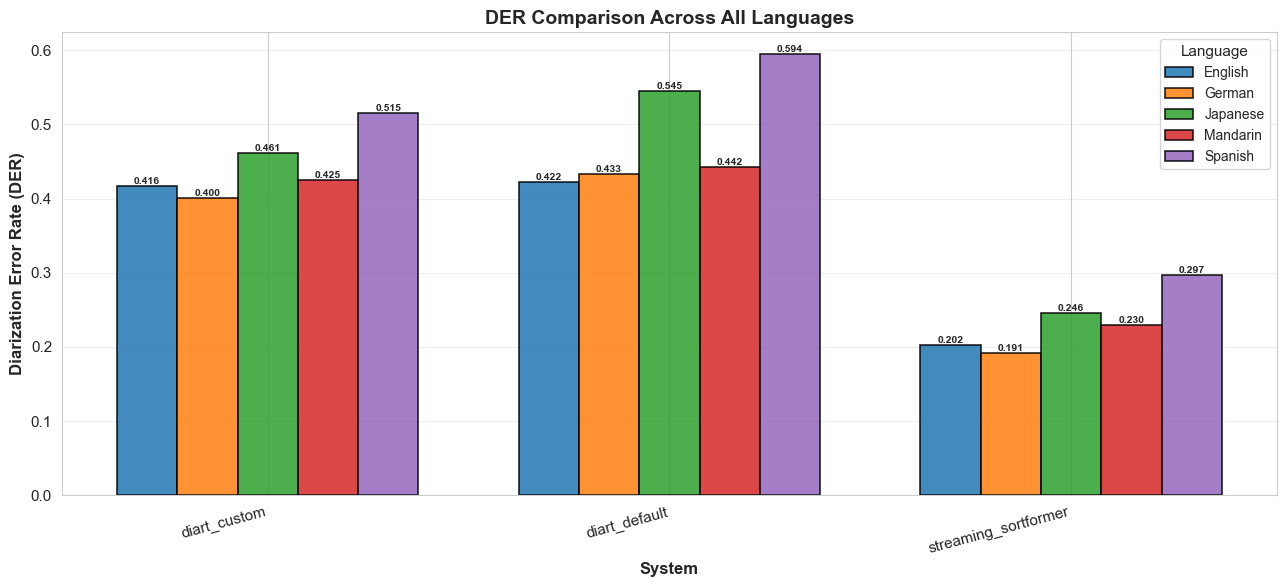

In [5]:
# Prepare data for plotting
metrics_summary = df_combined.groupby(['language', 'system']).agg({
    'DER': 'mean',
    'detection_error': 'mean',
    'JER': 'mean'
}).reset_index()

languages = metrics_summary['language'].unique()
systems = metrics_summary['system'].unique()
x = np.arange(len(systems))
n_langs = len(languages)
width = 0.75 / n_langs  # Dynamically size bars for any number of languages

# Create grouped bar chart for DER
fig, ax = plt.subplots(figsize=(13, 6))

for i, lang in enumerate(languages):
    lang_data = metrics_summary[metrics_summary['language'] == lang]
    offset = width * (i - (n_langs - 1) / 2)
    bars = ax.bar(x + offset, lang_data['DER'], width,
                  label=lang, alpha=0.85, edgecolor='black', linewidth=1.2)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Diarization Error Rate (DER)', fontsize=12, fontweight='bold')
ax.set_title('DER Comparison Across All Languages', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=15, ha='right')
ax.legend(title='Language', fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization: Detection Error Rate Comparison

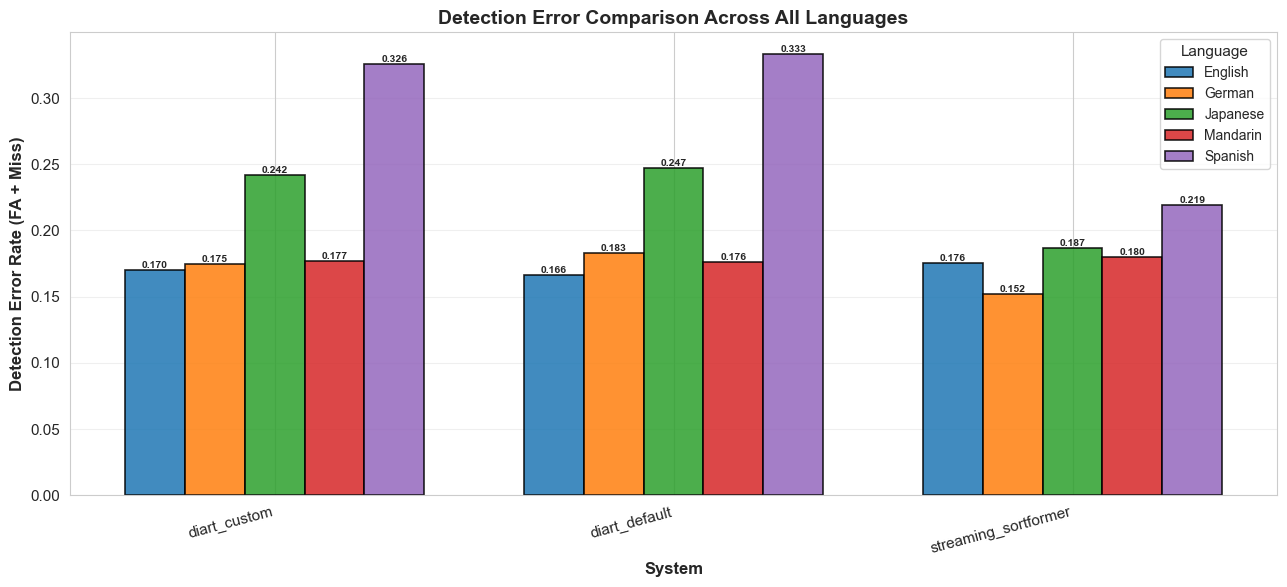

In [6]:
# Create grouped bar chart for Detection Error
fig, ax = plt.subplots(figsize=(13, 6))

for i, lang in enumerate(languages):
    lang_data = metrics_summary[metrics_summary['language'] == lang]
    offset = width * (i - (n_langs - 1) / 2)
    bars = ax.bar(x + offset, lang_data['detection_error'], width,
                  label=lang, alpha=0.85, edgecolor='black', linewidth=1.2)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Detection Error Rate (FA + Miss)', fontsize=12, fontweight='bold')
ax.set_title('Detection Error Comparison Across All Languages', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=15, ha='right')
ax.legend(title='Language', fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Visualization: JER Comparison

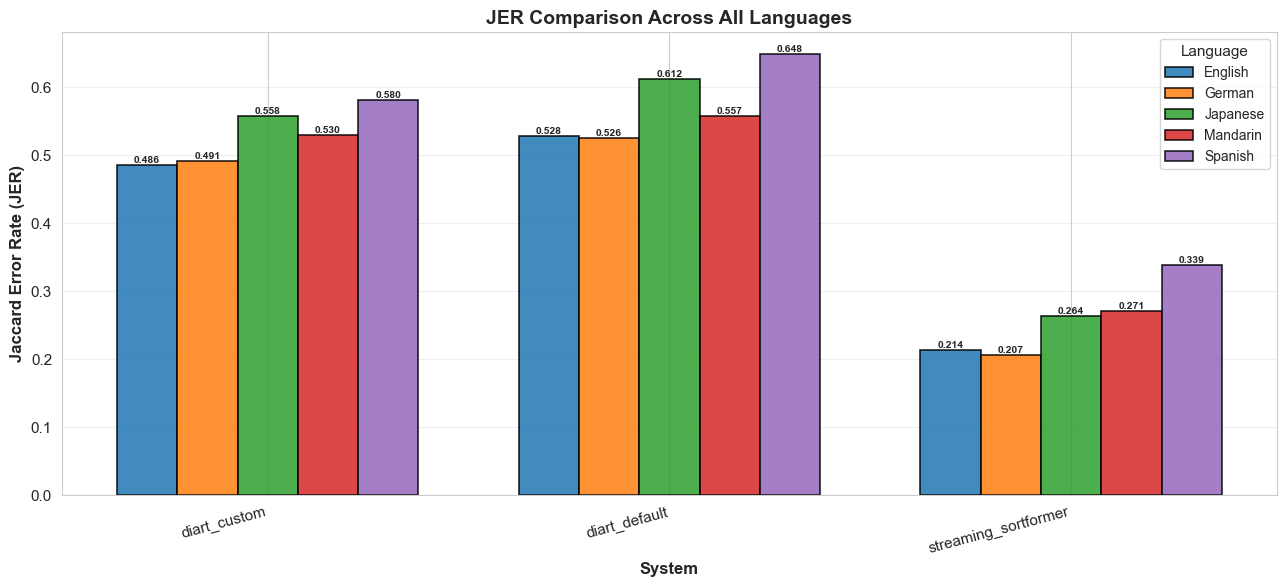

In [7]:
# Create grouped bar chart for JER
fig, ax = plt.subplots(figsize=(13, 6))

for i, lang in enumerate(languages):
    lang_data = metrics_summary[metrics_summary['language'] == lang]
    offset = width * (i - (n_langs - 1) / 2)
    bars = ax.bar(x + offset, lang_data['JER'], width,
                  label=lang, alpha=0.85, edgecolor='black', linewidth=1.2)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('System', fontsize=12, fontweight='bold')
ax.set_ylabel('Jaccard Error Rate (JER)', fontsize=12, fontweight='bold')
ax.set_title('JER Comparison Across All Languages', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(systems, rotation=15, ha='right')
ax.legend(title='Language', fontsize=10, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## All Metrics Side-by-Side Comparison

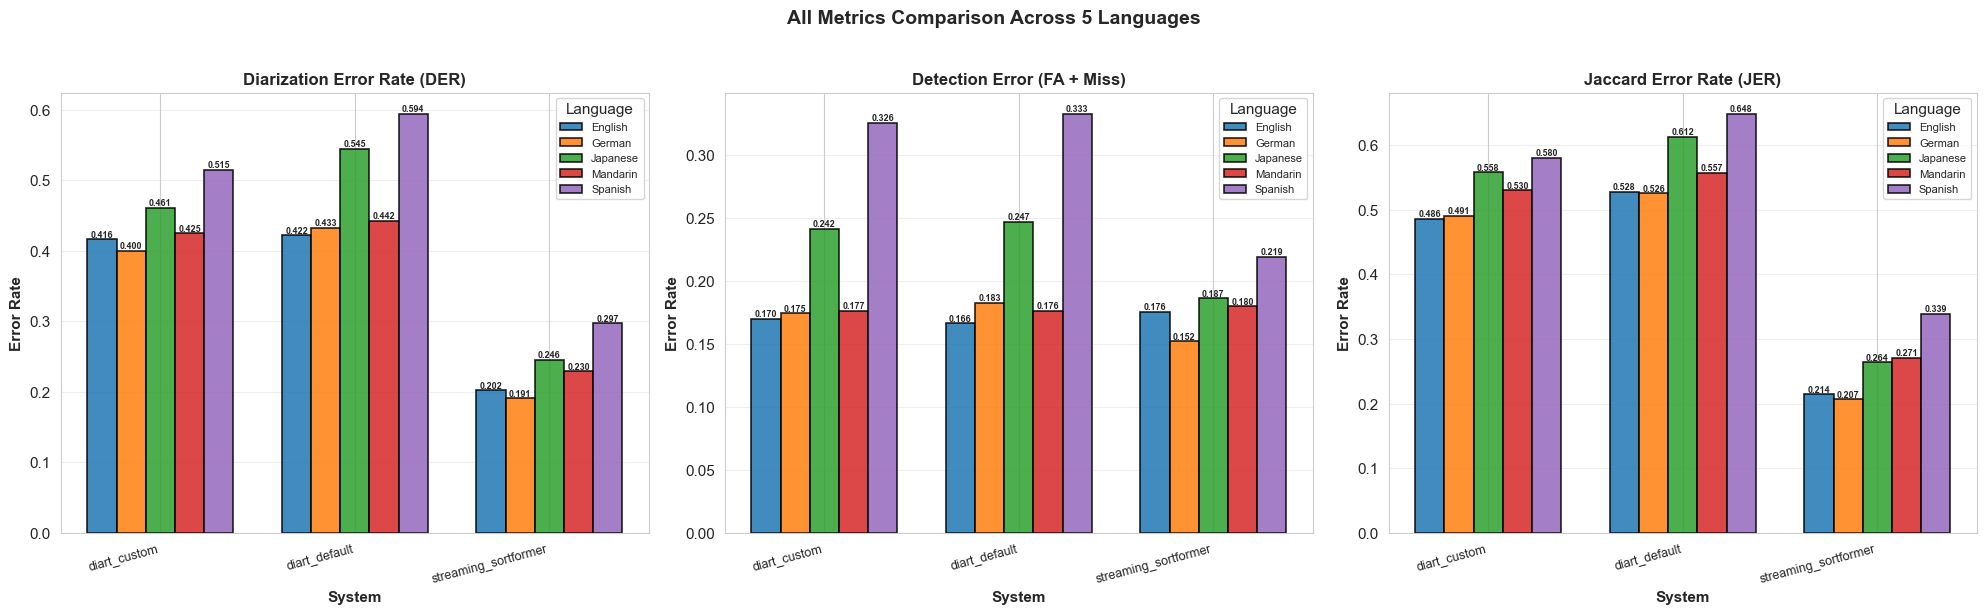

In [8]:
# Create comprehensive comparison with all three metrics side-by-side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metric_info = [
    ('DER', 'Diarization Error Rate (DER)', axes[0]),
    ('detection_error', 'Detection Error (FA + Miss)', axes[1]),
    ('JER', 'Jaccard Error Rate (JER)', axes[2])
]

for metric_name, title, ax in metric_info:
    for i, lang in enumerate(languages):
        lang_data = metrics_summary[metrics_summary['language'] == lang]
        offset = width * (i - (n_langs - 1) / 2)
        bars = ax.bar(x + offset, lang_data[metric_name], width,
                      label=lang, alpha=0.85, edgecolor='black', linewidth=1.2)

        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=6.5, fontweight='bold')

    ax.set_xlabel('System', fontsize=11, fontweight='bold')
    ax.set_ylabel('Error Rate', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(systems, rotation=15, ha='right', fontsize=9)
    ax.legend(title='Language', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('All Metrics Comparison Across 5 Languages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## System Ranking by Language

In [9]:
# Rank systems for each language based on DER
print("System Rankings by Language (DER - lower is better)")
print("="*80)

for lang in languages:
    lang_data = metrics_summary[metrics_summary['language'] == lang].sort_values('DER')
    print(f"\n{lang}:")
    for idx, (_, row) in enumerate(lang_data.iterrows(), 1):
        print(f"  {idx}. {row['system']:25s} - DER: {row['DER']:.4f}, "
              f"Det: {row['detection_error']:.4f}, JER: {row['JER']:.4f}")

System Rankings by Language (DER - lower is better)

English:
  1. streaming_sortformer      - DER: 0.2024, Det: 0.1757, JER: 0.2144
  2. diart_custom              - DER: 0.4162, Det: 0.1700, JER: 0.4857
  3. diart_default             - DER: 0.4221, Det: 0.1664, JER: 0.5276

German:
  1. streaming_sortformer      - DER: 0.1913, Det: 0.1524, JER: 0.2070
  2. diart_custom              - DER: 0.4005, Det: 0.1746, JER: 0.4908
  3. diart_default             - DER: 0.4329, Det: 0.1827, JER: 0.5257

Japanese:
  1. streaming_sortformer      - DER: 0.2458, Det: 0.1866, JER: 0.2643
  2. diart_custom              - DER: 0.4609, Det: 0.2416, JER: 0.5580
  3. diart_default             - DER: 0.5451, Det: 0.2471, JER: 0.6125

Mandarin:
  1. streaming_sortformer      - DER: 0.2295, Det: 0.1802, JER: 0.2705
  2. diart_custom              - DER: 0.4247, Det: 0.1766, JER: 0.5301
  3. diart_default             - DER: 0.4424, Det: 0.1765, JER: 0.5572

Spanish:
  1. streaming_sortformer      - DER: 0.2972,

## Language Difficulty Analysis

Which language is more challenging for diarization?

Language Difficulty Comparison (averaged across all systems):


,DER,detection_error,JER,gt_overlap_rate,gt_num_speakers
language,,,,,
Spanish,0.4689,0.2928,0.5224,0.1489,2.5429
Japanese,0.4172,0.2251,0.4783,0.1859,2.1917
Mandarin,0.3655,0.1778,0.4526,0.1093,2.7357
English,0.3469,0.1707,0.4092,0.0790,2.1000
German,0.3416,0.1699,0.4078,0.1114,2.1667


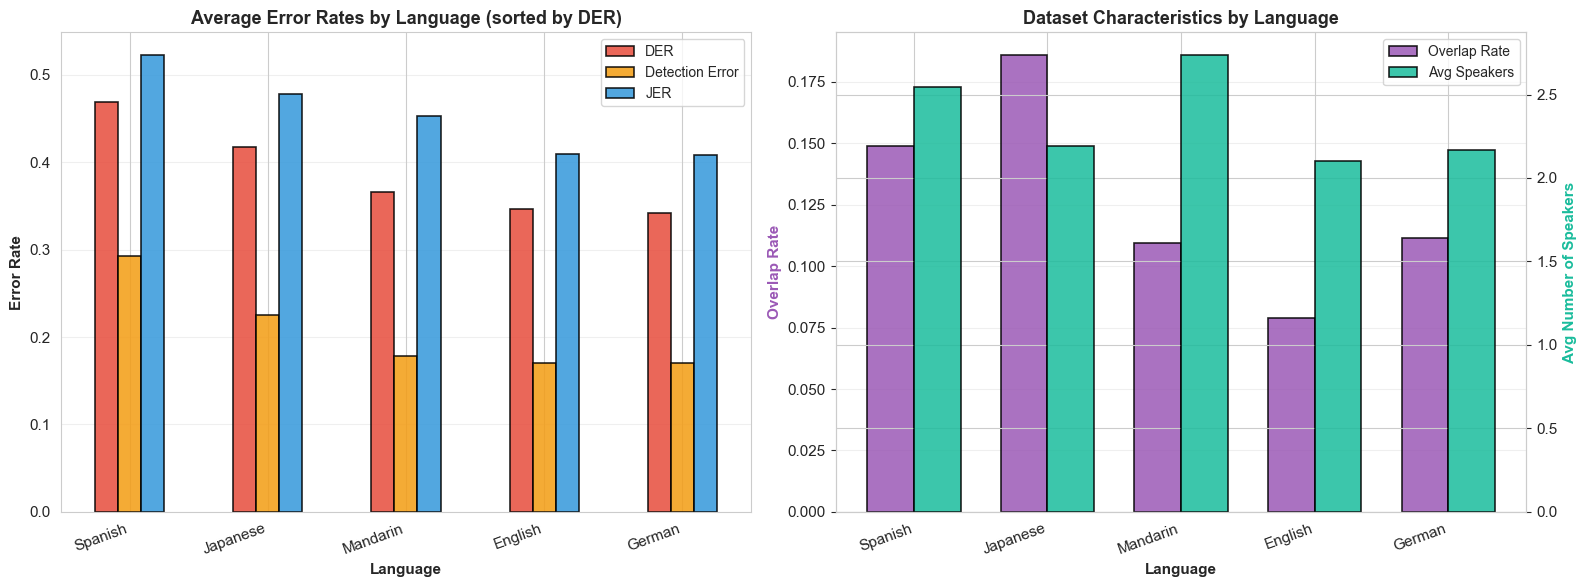

In [10]:
# Compare average performance across all systems, grouped by language
lang_difficulty = df_combined.groupby('language').agg({
    'DER': 'mean',
    'detection_error': 'mean',
    'JER': 'mean',
    'gt_overlap_rate': 'mean',
    'gt_num_speakers': 'mean'
}).round(4)

# Sort by DER descending (hardest first)
lang_difficulty = lang_difficulty.sort_values('DER', ascending=False)

print("Language Difficulty Comparison (averaged across all systems):")
print("=" * 80)
display(lang_difficulty)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Error rates
metrics_to_plot = ['DER', 'detection_error', 'JER']
lang_difficulty[metrics_to_plot].plot(kind='bar', ax=axes[0],
                                      color=['#e74c3c', '#f39c12', '#3498db'],
                                      alpha=0.85, edgecolor='black', linewidth=1.2)
axes[0].set_title('Average Error Rates by Language (sorted by DER)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Language', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Error Rate', fontsize=11, fontweight='bold')
axes[0].legend(['DER', 'Detection Error', 'JER'], fontsize=10)
axes[0].set_xticklabels(lang_difficulty.index, rotation=20, ha='right')
axes[0].grid(axis='y', alpha=0.3)

# Dataset characteristics: overlap rate and num speakers on separate y-axes
ax2 = axes[1]
ax2_twin = ax2.twinx()

x_pos = np.arange(len(lang_difficulty))
bar_w = 0.35
bars1 = ax2.bar(x_pos - bar_w / 2, lang_difficulty['gt_overlap_rate'], bar_w,
                label='Overlap Rate', color='#9b59b6', alpha=0.85, edgecolor='black', linewidth=1.2)
bars2 = ax2_twin.bar(x_pos + bar_w / 2, lang_difficulty['gt_num_speakers'], bar_w,
                     label='Avg Speakers', color='#1abc9c', alpha=0.85, edgecolor='black', linewidth=1.2)

ax2.set_title('Dataset Characteristics by Language', fontsize=13, fontweight='bold')
ax2.set_xlabel('Language', fontsize=11, fontweight='bold')
ax2.set_ylabel('Overlap Rate', fontsize=11, fontweight='bold', color='#9b59b6')
ax2_twin.set_ylabel('Avg Number of Speakers', fontsize=11, fontweight='bold', color='#1abc9c')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(lang_difficulty.index, rotation=20, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


## Key Findings Summary

In [11]:
# Generate key findings
print("="*80)
print("KEY FINDINGS: Cross-Language Performance Comparison")
print("="*80)

# Best system overall
best_overall = summary.groupby('system')[['DER', 'detection_error', 'JER']].mean().idxmin()
print(f"\nBest Overall Systems:")
print(f"  - DER: {best_overall['DER']}")
print(f"  - Detection Error: {best_overall['detection_error']}")
print(f"  - JER: {best_overall['JER']}")

# Language difficulty
avg_by_lang = df_combined.groupby('language')[['DER', 'detection_error', 'JER']].mean()
harder_lang_der = avg_by_lang['DER'].idxmax()
easier_lang_der = avg_by_lang['DER'].idxmin()

print(f"\nLanguage Difficulty (based on average DER):")
print(f"  - More challenging: {harder_lang_der} (DER: {avg_by_lang.loc[harder_lang_der, 'DER']:.4f})")
print(f"  - Less challenging: {easier_lang_der} (DER: {avg_by_lang.loc[easier_lang_der, 'DER']:.4f})")

print("\n" + "="*80)

KEY FINDINGS: Cross-Language Performance Comparison

Best Overall Systems:
  - DER: streaming_sortformer
  - Detection Error: streaming_sortformer
  - JER: streaming_sortformer

Language Difficulty (based on average DER):
  - More challenging: Spanish (DER: 0.4689)
  - Less challenging: German (DER: 0.3416)



## Latency Analysis

For streaming systems the latency perceived by a downstream application (e.g. emergency call routing) consists of two components:

1. **Buffer fill time** — audio that must accumulate before a forward pass can be triggered.  
   - DiArt (steady-state): one step = 500 ms; first output requires filling the full 5 s window.  
   - Sortformer: one chunk = ~1040 ms (both steady-state and first output).

2. **Computational latency** — wall-clock time for the model forward pass.

Two derived E2E metrics are compared:
- **Steady-state E2E** = buffer fill + mean computational latency (typical per-step latency after warm-up)
- **First-output E2E** = window fill + peak computational latency (worst-case time until the very first result — most relevant for emergency use)

In [ ]:
# Compute E2E latency columns on the combined dataset
df_latency = stats_report.compute_e2e_latency(df_combined)

# Aggregate by system (averaged across all languages and recordings)
latency_summary = df_latency.groupby('system').agg(
    comp_mean_ms        =('latency_mean_ms',        'mean'),
    comp_std_ms         =('latency_std_ms',         'mean'),
    comp_peak_ms        =('peak_latency_ms',        'mean'),
    e2e_steady_ms       =('e2e_steady_ms',          'mean'),
    e2e_first_output_ms =('e2e_first_output_ms',    'mean'),
    buffer_fill_ms      =('buffer_fill_ms',          'first'),
    first_fill_ms       =('first_fill_ms',            'first'),
).round(1)

print("End-to-End Latency Summary (averaged across all languages)")
print("="*70)
display(latency_summary[['buffer_fill_ms', 'first_fill_ms',
                          'comp_mean_ms', 'comp_std_ms', 'comp_peak_ms',
                          'e2e_steady_ms', 'e2e_first_output_ms']])

stats_report.print_e2e_latency_statistics(df_latency)

In [ ]:
## Visualization: E2E Latency Comparison

systems_ordered = ['diart_default', 'diart_custom', 'streaming_sortformer']
latency_plot = latency_summary.reindex(systems_ordered).dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(latency_plot))
width = 0.35
colors = {'comp_mean_ms': '#3498db', 'buffer_fill_ms': '#95a5a6',
          'comp_peak_ms': '#e74c3c', 'first_fill_ms': '#bdc3c7'}

# --- Left: steady-state E2E (stacked: buffer fill + mean comp) ---
ax = axes[0]
bars_buf = ax.bar(x, latency_plot['buffer_fill_ms'], width*2,
                  label='Buffer fill (500 ms)', color=colors['buffer_fill_ms'],
                  edgecolor='black', linewidth=0.8)
bars_comp = ax.bar(x, latency_plot['comp_mean_ms'], width*2,
                   bottom=latency_plot['buffer_fill_ms'],
                   label='Mean computational', color=colors['comp_mean_ms'],
                   edgecolor='black', linewidth=0.8)
for bar, total in zip(bars_comp, latency_plot['e2e_steady_ms']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() + 8,
            f'{total:.0f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('Steady-State E2E Latency', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (ms)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(latency_plot.index, rotation=15, ha='right')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- Right: first-output E2E (stacked: window fill + peak comp) ---
ax = axes[1]
bars_win = ax.bar(x, latency_plot['first_fill_ms'], width*2,
                  label='Window fill', color=colors['first_fill_ms'],
                  edgecolor='black', linewidth=0.8)
bars_peak = ax.bar(x, latency_plot['comp_peak_ms'], width*2,
                   bottom=latency_plot['first_fill_ms'],
                   label='Peak computational', color=colors['comp_peak_ms'],
                   edgecolor='black', linewidth=0.8)
for bar, total in zip(bars_peak, latency_plot['e2e_first_output_ms']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_y() + bar.get_height() + 8,
            f'{total:.0f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('First-Output E2E Latency\n(worst-case, emergency-relevant)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (ms)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(latency_plot.index, rotation=15, ha='right')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.suptitle('End-to-End Latency Breakdown by System', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/e2e_latency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../results/e2e_latency_comparison.png")